# Implied Volatility Surface Time Series

Production-grade notebook for building implied-volatility surfaces from option quotes. Each surface uses strike price and maturity on the axes, with implied volatility as the value. If a quote-history file is supplied, the notebook builds a true time series of surfaces; otherwise it can fetch a current Yahoo Finance option-chain snapshot or generate a deterministic demo dataset so the pipeline remains executable.

## Methodology

- Implied volatility is treated as the volatility that makes the pricing model match the observed option price at a given strike and maturity.
- Listed option quotes are cleaned before interpolation: positive maturity, bounded moneyness, valid bid/ask or last price, spread filter, open-interest filter, and IV bounds.
- Missing or invalid IV values are recovered from bid/ask mid prices with a Black-Scholes bisection solver.
- Interpolation is applied in total implied variance space, then converted back to IV. This is more stable across maturities than interpolating raw IV directly.
- Irregular option-chain points are interpolated with SciPy `griddata` when available, with a Matplotlib triangulation fallback.

References checked while building this notebook:

- Cboe theoretical options calculation methodology: https://cdn.cboe.com/api/global/us_indices/governance/Cboe_American_and_European-Style_Theoretical_Options_Calculation_Methodology.pdf
- QuantLib volatility term-structure documentation: https://quantlib-python-docs.readthedocs.io/en/latest/termstructures/volatility.html
- SciPy `griddata` documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.griddata.html
- Matplotlib irregular grid contour guidance: https://matplotlib.org/stable/gallery/images_contours_and_fields/irregulardatagrid.html
- yfinance documentation: https://ranaroussi.github.io/yfinance/

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from features.implied_volatility_surface import (
    SurfaceConfig,
    animate_surface_timeseries,
    build_synthetic_option_timeseries,
    clean_option_quotes,
    fetch_yahoo_option_snapshot,
    load_option_quotes,
    plot_feature_timeseries,
    plot_smile_by_maturity,
    plot_surface_3d,
    plot_surface_heatmap,
    select_surface_snapshot,
    snapshot_dates,
    summarize_surface_features,
)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print("Imports OK")

Imports OK


## Configuration

`DATA_MODE` can be `auto`, `file`, `yahoo`, or `synthetic`. For a real time series, set `DATA_MODE = "file"` and point `QUOTE_DATA_PATH` to a CSV or parquet file with quote history.

In [2]:
DATA_MODE = "auto"  # auto, file, yahoo, synthetic
QUOTE_DATA_PATH = Path("data/options/option_quote_history.parquet")
YAHOO_MAX_EXPIRATIONS = 12
SYNTHETIC_DEMO_QUOTE_DATES = 126  # approx. six months of business days
ALLOW_SYNTHETIC_FALLBACK = True

config = SurfaceConfig(
    ticker="AAPL",
    option_type="call",       # call, put, or both
    risk_free_rate=0.045,
    dividend_yield=0.0,
    min_days_to_expiry=7,
    max_days_to_expiry=540,
    min_moneyness=0.70,
    max_moneyness=1.30,
    max_spread_pct=0.35,
    min_open_interest=0,
    grid_strikes=80,
    grid_maturities=50,
    output_dir=Path("images/implied_vol_surface"),
)
config.output_dir.mkdir(parents=True, exist_ok=True)

print(config)

SurfaceConfig(ticker='AAPL', option_type='call', risk_free_rate=0.045, dividend_yield=0.0, min_days_to_expiry=7, max_days_to_expiry=540, min_moneyness=0.7, max_moneyness=1.3, min_iv=0.01, max_iv=3.0, max_spread_pct=0.35, min_open_interest=0, grid_strikes=80, grid_maturities=50, interpolation_method='linear', output_dir=PosixPath('images/implied_vol_surface'))


## Expected Quote-History Schema

Required columns, with common aliases accepted:

- `quote_date`: quote snapshot date or timestamp
- `expiration`: option expiration date
- `strike`: strike price
- `option_type`: `call` or `put`; `C` and `P` are accepted
- `underlying_price`: spot price at quote time

Recommended columns:

- `bid`, `ask`: preferred, used to compute mid price and spread quality
- `mid_price` or `last_price`: fallback option price
- `implied_volatility`: decimal IV, e.g. `0.25` for 25 percent
- `volume`, `open_interest`, `contract_symbol`: retained for auditability

In [3]:
raw_quotes = None
data_source = None
load_errors = []

if DATA_MODE in {"auto", "file"}:
    if QUOTE_DATA_PATH.exists():
        raw_quotes = load_option_quotes(QUOTE_DATA_PATH)
        data_source = f"file:{QUOTE_DATA_PATH}"
    elif DATA_MODE == "file":
        raise FileNotFoundError(QUOTE_DATA_PATH)

if raw_quotes is None and DATA_MODE in {"auto", "yahoo"}:
    try:
        raw_quotes = fetch_yahoo_option_snapshot(
            config.ticker,
            config,
            max_expirations=YAHOO_MAX_EXPIRATIONS,
        )
        data_source = f"yahoo_snapshot:{config.ticker}"
    except Exception as exc:
        load_errors.append(f"Yahoo fetch failed: {exc}")
        if DATA_MODE == "yahoo":
            raise

if raw_quotes is None and (DATA_MODE == "synthetic" or ALLOW_SYNTHETIC_FALLBACK):
    raw_quotes = build_synthetic_option_timeseries(config, quote_dates=SYNTHETIC_DEMO_QUOTE_DATES, spot=100.0)
    data_source = "synthetic_demo"

if raw_quotes is None:
    raise RuntimeError("No option quotes loaded. Provide QUOTE_DATA_PATH or enable another DATA_MODE.")

print(f"Data source: {data_source}")
print(f"Raw rows: {len(raw_quotes):,}")
if load_errors:
    print("Load warnings:")
    for error in load_errors:
        print(f"  - {error}")
display(raw_quotes.head())

Data source: yahoo_snapshot:AAPL
Raw rows: 616


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,option_type,expiration,quote_date,underlying_price
0,AAPL260713C00205000,2026-07-02 17:58:31+00:00,205.0,102.68,108.65,112.15,0.0,0.0,2.0,1,1.878907,True,REGULAR,USD,call,2026-07-13,2026-07-11 14:54:31.302241,315.320007
1,AAPL260713C00210000,2026-07-02 17:58:31+00:00,210.0,97.71,103.60,107.25,0.0,0.0,2.0,1,1.839845,True,REGULAR,USD,call,2026-07-13,2026-07-11 14:54:31.302241,315.320007
2,AAPL260713C00225000,2026-06-29 14:54:22+00:00,225.0,58.24,88.55,92.30,0.0,0.0,NaN,1,1.558596,True,REGULAR,USD,call,2026-07-13,2026-07-11 14:54:31.302241,315.320007
3,AAPL260713C00230000,2026-07-09 13:46:07+00:00,230.0,81.13,83.55,87.05,0.0,0.0,2.0,7,2.344242,True,REGULAR,USD,call,2026-07-13,2026-07-11 14:54:31.302241,315.320007
4,AAPL260713C00255000,2026-07-09 18:12:19+00:00,255.0,60.30,58.55,62.30,0.0,0.0,290.0,58,1.031255,True,REGULAR,USD,call,2026-07-13,2026-07-11 14:54:31.302241,315.320007


In [4]:
clean_quotes = clean_option_quotes(raw_quotes, config)
dates = snapshot_dates(clean_quotes)

print(f"Clean rows: {len(clean_quotes):,}")
print(f"Quote dates: {len(dates):,}")
print(f"Date range: {dates[0].date()} -> {dates[-1].date()}")
print(f"Expirations: {clean_quotes['expiration'].nunique():,}")
print(f"Strike range: {clean_quotes['strike'].min():.2f} -> {clean_quotes['strike'].max():.2f}")
print(f"IV range: {clean_quotes['implied_volatility'].min()*100:.2f}% -> {clean_quotes['implied_volatility'].max()*100:.2f}%")

display(clean_quotes.head())

Clean rows: 257
Quote dates: 1
Date range: 2026-07-11 -> 2026-07-11
Expirations: 9
Strike range: 225.00 -> 400.00
IV range: 22.54% -> 88.62%


,quote_date,expiration,dte,tau,strike,underlying_price,moneyness,option_type,bid,ask,mid_price,last_price,spread_pct,implied_volatility,iv_source,volume,open_interest,contract_symbol
156,2026-07-11,2026-07-20,9.0,0.024641,235.0,315.320007,0.745275,call,78.95,82.25,80.600,79.00,0.040943,0.862306,provided,NaN,0,AAPL260720C00235000
157,2026-07-11,2026-07-20,9.0,0.024641,240.0,315.320007,0.761132,call,73.90,77.35,75.625,74.00,0.045620,0.818849,provided,NaN,0,AAPL260720C00240000
158,2026-07-11,2026-07-20,9.0,0.024641,265.0,315.320007,0.840416,call,48.90,52.30,50.600,50.18,0.067194,0.548833,provided,8.0,0,AAPL260720C00265000
159,2026-07-11,2026-07-20,9.0,0.024641,270.0,315.320007,0.856273,call,43.85,47.35,45.600,45.20,0.076754,0.772097,provided,9.0,1,AAPL260720C00270000
160,2026-07-11,2026-07-20,9.0,0.024641,275.0,315.320007,0.872130,call,39.25,42.30,40.775,39.95,0.074801,0.698978,provided,4.0,2,AAPL260720C00275000


In [5]:
features = summarize_surface_features(clean_quotes)
display(features.tail(10))

,quote_date,option_type,quote_count,expiration_count,spot,atm_iv,mean_iv,median_iv,term_slope_far_minus_near,downside_minus_upside_skew,min_dte,max_dte,min_strike,max_strike
0,2026-07-11,call,257,9,315.320007,0.270942,0.401054,0.352851,0.023834,0.158483,9.0,97.0,225.0,400.0


## Latest Surface Snapshot

The chart axes are strike price and maturity in calendar days. The z-axis or color value is implied volatility.

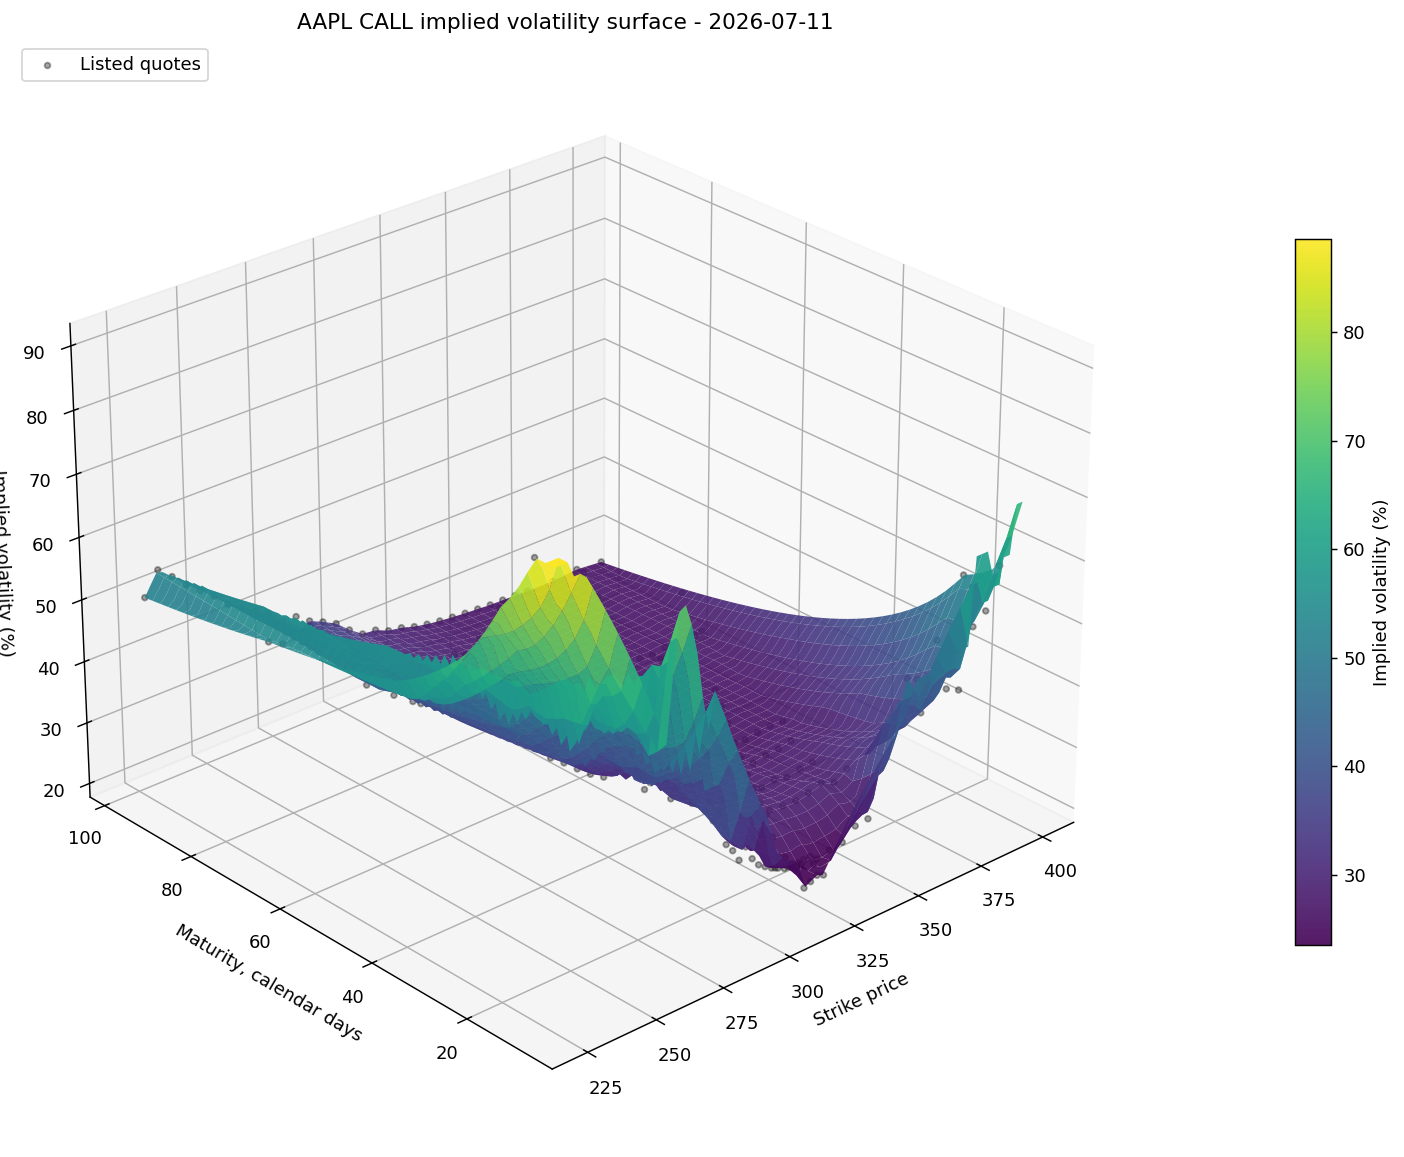

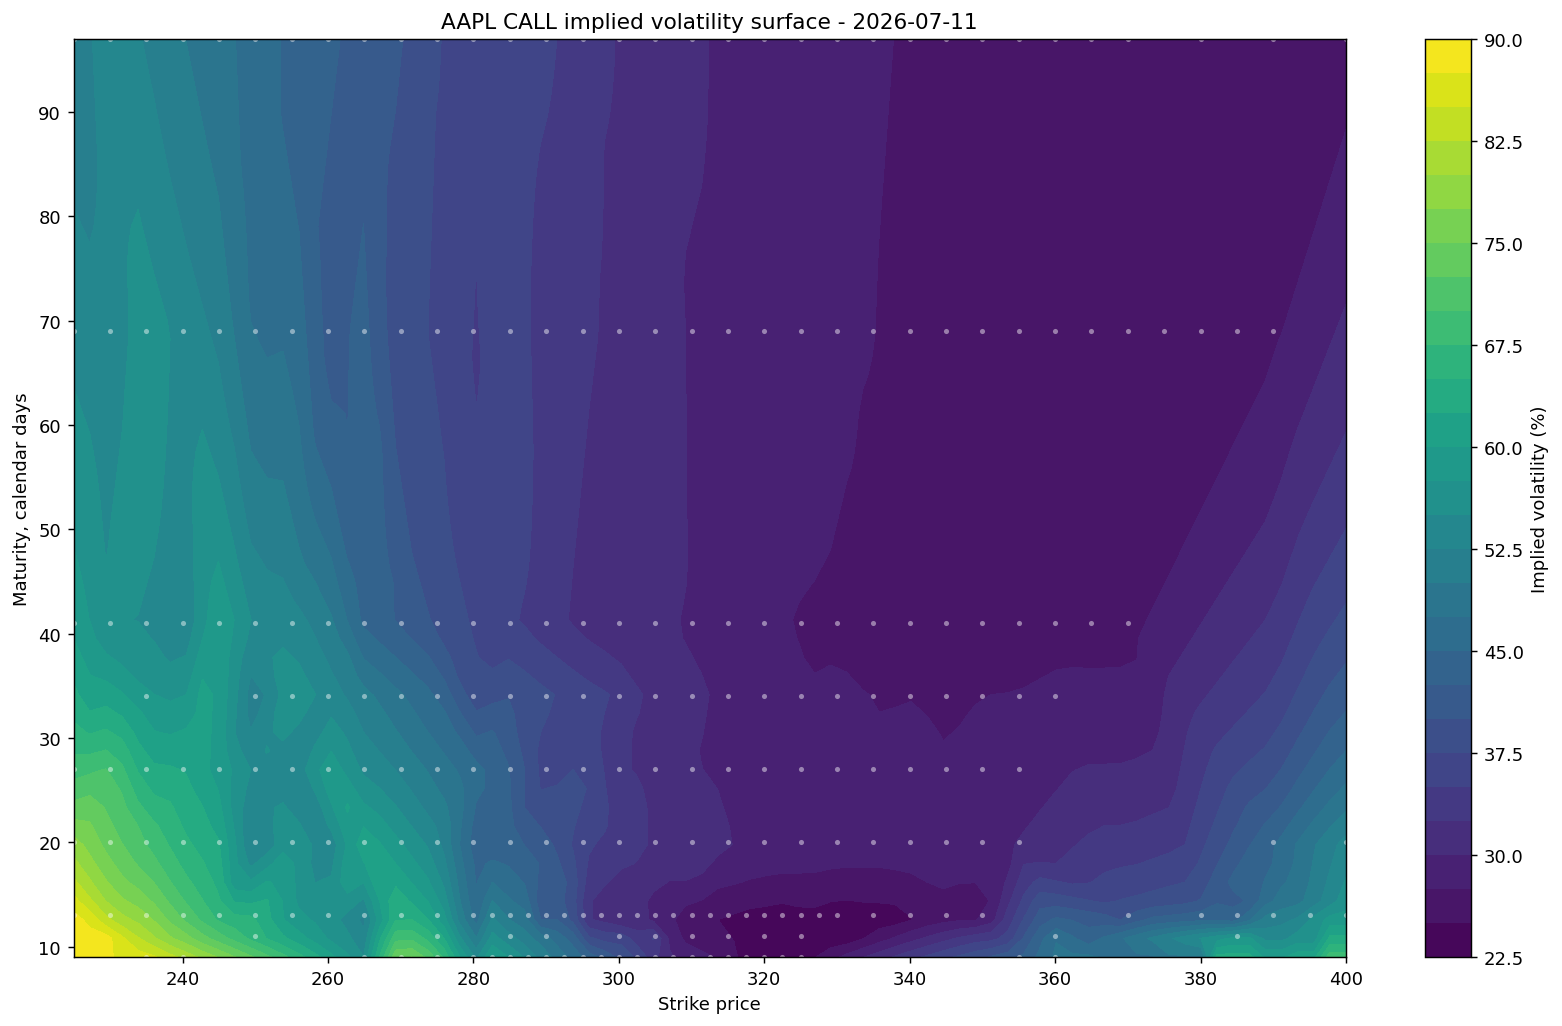

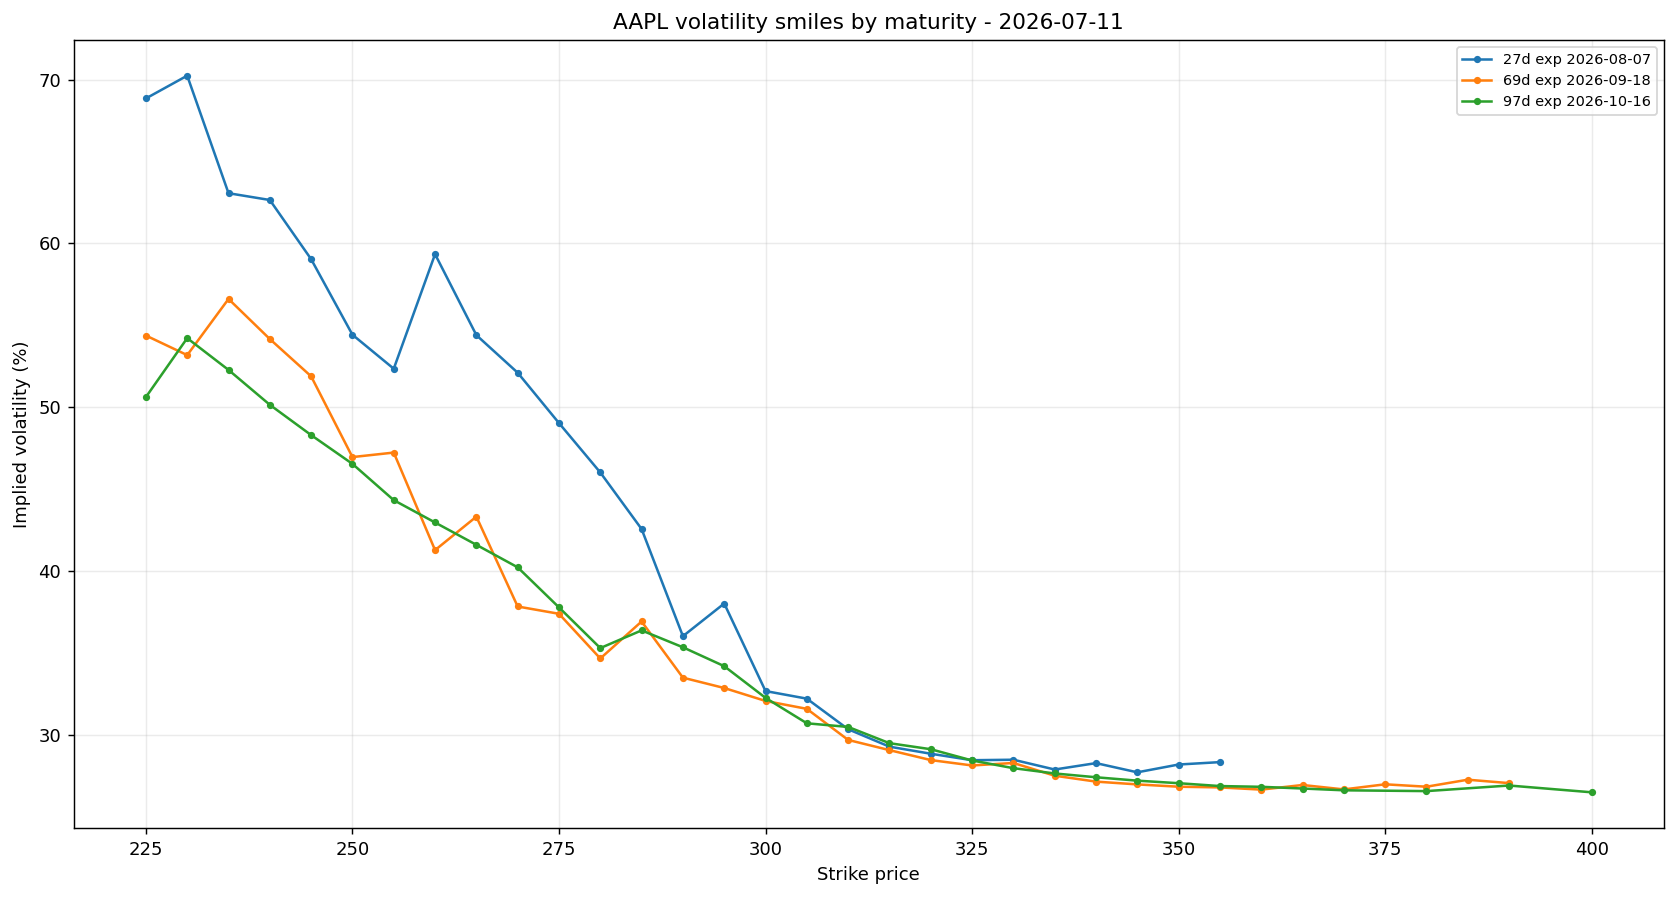

Saved: images/implied_vol_surface/AAPL_call_2026-07-11_surface_3d.png
Saved: images/implied_vol_surface/AAPL_call_2026-07-11_surface_heatmap.png
Saved: images/implied_vol_surface/AAPL_call_2026-07-11_smiles.png


In [6]:
snapshot = select_surface_snapshot(clean_quotes, option_type=config.option_type)
snapshot_date = pd.Timestamp(snapshot['quote_date'].iloc[0]).date()
selected_type = snapshot['option_type'].iloc[0] if config.option_type != 'both' else 'both'
base_title = f"{config.ticker} {selected_type.upper()} implied volatility surface - {snapshot_date}"

surface_png = config.output_dir / f"{config.ticker}_{selected_type}_{snapshot_date}_surface_3d.png"
heatmap_png = config.output_dir / f"{config.ticker}_{selected_type}_{snapshot_date}_surface_heatmap.png"
smile_png = config.output_dir / f"{config.ticker}_{selected_type}_{snapshot_date}_smiles.png"

fig_3d = plot_surface_3d(snapshot, config, base_title, x_axis="strike", save_path=surface_png)
plt.show()

fig_heatmap = plot_surface_heatmap(snapshot, config, base_title, x_axis="strike", save_path=heatmap_png)
plt.show()

fig_smile = plot_smile_by_maturity(snapshot, f"{config.ticker} volatility smiles by maturity - {snapshot_date}", x_axis="strike", save_path=smile_png)
plt.show()

print(f"Saved: {surface_png}")
print(f"Saved: {heatmap_png}")
print(f"Saved: {smile_png}")

## Surface Feature Time Series

For real quote-history input this tracks how ATM IV, term slope, and skew evolve over quote dates. A single Yahoo snapshot will naturally produce only one point.

In [7]:
feature_png = config.output_dir / f"{config.ticker}_surface_features.png"
if features['quote_date'].nunique() > 1:
    fig_features = plot_feature_timeseries(features, f"{config.ticker} implied volatility surface features", save_path=feature_png)
    plt.show()
    print(f"Saved: {feature_png}")
else:
    print("Only one quote date is available; feature time-series plot skipped.")

Only one quote date is available; feature time-series plot skipped.


## Surface Video Over Time

The video uses cleaned quote-history snapshots when at least two quote dates are available. A Yahoo snapshot has only one quote date, so this notebook generates a clearly labeled synthetic demo video in that case; replace `QUOTE_DATA_PATH` with real historical option quotes to animate real market history.

In [8]:
from IPython.display import Video, display

VIDEO_MAX_FRAMES = 90
VIDEO_FPS = 5

video_quotes = clean_quotes
video_source = data_source
video_label = "real_history"

if clean_quotes['quote_date'].nunique() < 2:
    print("Only one quote date is available from the loaded source; generating a labeled synthetic demo video.")
    demo_spot = float(clean_quotes['underlying_price'].median())
    video_raw_quotes = build_synthetic_option_timeseries(config, quote_dates=SYNTHETIC_DEMO_QUOTE_DATES, spot=demo_spot, seed=11)
    video_quotes = clean_option_quotes(video_raw_quotes, config)
    video_source = "synthetic_demo_for_animation"
    video_label = "synthetic_demo"

video_type = "call" if config.option_type == "both" else config.option_type
video_path = config.output_dir / f"{config.ticker}_{video_type}_surface_timeseries_{video_label}.mp4"
video_title = f"{config.ticker} {video_type.upper()} implied volatility surface over time ({video_source})"

video_path = animate_surface_timeseries(
    video_quotes,
    config,
    title=video_title,
    option_type=video_type,
    x_axis="strike",
    max_frames=VIDEO_MAX_FRAMES,
    fps=VIDEO_FPS,
    save_path=video_path,
)

print(f"Video source: {video_source}")
print(f"Video quote dates: {video_quotes['quote_date'].nunique():,}")
print(f"Saved: {video_path}")
display(Video(str(video_path), embed=False, html_attributes="controls muted loop"))

Only one quote date is available from the loaded source; generating a labeled synthetic demo video.


Video source: synthetic_demo_for_animation
Video quote dates: 126
Saved: images/implied_vol_surface/AAPL_call_surface_timeseries_synthetic_demo.mp4


In [9]:
clean_path = config.output_dir / f"{config.ticker}_clean_option_quotes.csv"
snapshot_path = config.output_dir / f"{config.ticker}_{selected_type}_{snapshot_date}_snapshot.csv"
features_path = config.output_dir / f"{config.ticker}_surface_features.csv"

clean_quotes.to_csv(clean_path, index=False)
snapshot.to_csv(snapshot_path, index=False)
features.to_csv(features_path, index=False)

print("Exported datasets:")
print(f"  {clean_path}")
print(f"  {snapshot_path}")
print(f"  {features_path}")
print(f"  {video_path}")
print("Notebook complete")

Exported datasets:
  images/implied_vol_surface/AAPL_clean_option_quotes.csv
  images/implied_vol_surface/AAPL_call_2026-07-11_snapshot.csv
  images/implied_vol_surface/AAPL_surface_features.csv
  images/implied_vol_surface/AAPL_call_surface_timeseries_synthetic_demo.mp4
Notebook complete
